In [109]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [71]:
from google.cloud import bigquery

client = bigquery.Client(project="groova-pml-20261")

table_name = "groova-pml-20261.groova_features.groova_features_1000"

c:\Users\gabri\miniconda3\envs\conda-ML\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [73]:
query = f"""
SELECT *
FROM {table_name}
LIMIT 1000
"""

df = client.query(query).to_dataframe()

c:\Users\gabri\miniconda3\envs\conda-ML\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [77]:
query = f"""
SELECT ID_ARTISTA, nota, valor_oferta 
FROM groova-pml-20261.groova_base_full.groova_dataset_raw
LIMIT 1000
"""

df_raw = client.query(query).to_dataframe()

c:\Users\gabri\miniconda3\envs\conda-ML\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
df_raw.rename(columns={'ID_ARTISTA': 'artist_id'}, inplace=True)
df.rename(columns={'ID_ARTISTA': 'artist_id'}, inplace=True)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 55 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   artist_key               790 non-null    object 
 1   artist_name              790 non-null    object 
 2   ID_ARTISTA               790 non-null    Int64  
 3   estilo                   790 non-null    object 
 4   formacao                 790 non-null    object 
 5   cidade                   790 non-null    object 
 6   uf                       790 non-null    object 
 7   video_url                790 non-null    object 
 8   video_title              790 non-null    object 
 9   video_channel            790 non-null    object 
 10  video_duration_sec       790 non-null    Int64  
 11  segment_start_sec        790 non-null    float64
 12  segment_duration_sec     790 non-null    Int64  
 13  duration_sec             790 non-null    float64
 14  sample_rate              7

# Esquema e Tipos

In [17]:
df.describe()

,ID_ARTISTA,video_duration_sec,segment_start_sec,segment_duration_sec,duration_sec,sample_rate,tempo_bpm,rms_mean,rms_std,zcr_mean,...,chroma_05_mean,chroma_06_mean,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std
count,790.0,790.0,790.000000,790.0,790.000000,790.0,790.000000,790.000000,790.000000,790.000000,...,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000
mean,14171.483544,617.774684,354.384430,10.0,14.329212,22050.0,119.917566,0.183019,0.057512,0.084260,...,0.358768,0.324395,0.336860,0.354619,0.342818,0.370077,0.326535,0.346606,1.420900,1.442629
std,5719.684214,1704.667252,1209.157266,0.0,3.059143,0.0,26.532988,0.082737,0.026244,0.034839,...,0.114974,0.107911,0.113133,0.120060,0.108775,0.116724,0.104497,0.112486,0.264467,0.525613
min,1288.0,45.0,0.000000,10.0,9.993515,22050.0,51.679688,0.017148,0.005886,0.018116,...,0.075057,0.056667,0.064962,0.044021,0.069190,0.073074,0.069746,0.041648,0.720700,0.386259
25%,11262.75,145.0,43.862500,10.0,11.573515,22050.0,99.384014,0.122193,0.038344,0.060526,...,0.278891,0.245832,0.257898,0.275393,0.268339,0.290011,0.256508,0.268120,1.222501,1.062775
50%,15203.0,198.5,84.740000,10.0,14.273515,22050.0,117.453835,0.178487,0.054593,0.081376,...,0.349724,0.313430,0.326324,0.348262,0.332974,0.363564,0.314299,0.337074,1.390900,1.396878
75%,18685.5,269.75,144.055000,10.0,16.873515,22050.0,135.999178,0.241794,0.074371,0.101520,...,0.429007,0.393673,0.400208,0.417900,0.409756,0.437399,0.389118,0.414873,1.579620,1.748841
max,22654.0,15265.0,12878.630000,10.0,19.973515,22050.0,215.332031,0.440639,0.215223,0.431723,...,0.776938,0.723784,0.774388,0.794124,0.720491,0.809558,0.717134,0.784880,2.669143,4.460619


De uma exploração inicial, parece que as features de chroma_mean e mfcc_mean são extremamente similar, com desvio padrão, min e max similares entre si, pode ser interessante aplicar algo sobre estes dados. As variaveis de Spectroid podem ser interessantes tambem fazer algo sobre.

## Features de metadados do áudio:

video_duration_sec — duração total do vídeo em segundos.

audio_total_duration_sec — duração total do áudio extraído, em segundos.

segment_n_used — quantidade de segmentos do áudio que foram usados para extrair as features (provavelmente o áudio foi dividido em trechos).

segment_duration_sec — duração de cada segmento em segundos.

feature_sampling_mode — método usado para amostrar/agregar as features dos segmentos (ex: média, mediana, etc.).

## Features temporais / rítmicas:

tempo_bpm — estimativa do andamento da música em batidas por minuto. Valores mais altos indicam músicas mais rápidas.

onset_strength_mean / _std — mede a intensidade dos "ataques" sonoros, ou seja, o quão marcadas são as transições de silêncio para som (ou de um som para outro). Está diretamente relacionado à percussividade: bateria forte e ataques de guitarra geram onset strength alto. A média (mean) indica o nível geral de percussividade, e o desvio padrão (std) indica o quanto essa percussividade varia ao longo do tempo.

## Features de energia e cruzamento por zero:

rms_mean / _std — Root Mean Square. Mede a energia do sinal. Quanto maior o RMS, mais alto/potente o som. A média reflete o volume geral da faixa, e o std indica variação dinâmica (uma música com muitas partes suaves e altas terá std alto).

zcr_mean / _std — Zero Crossing Rate, a taxa com que o sinal cruza o eixo zero (muda de positivo para negativo). Mede ruidosidade e "textura" do som. Sons mais agudos e ruidosos têm ZCR alto; sons graves e tonais têm ZCR baixo.
Features espectrais:
spectral_centroid_mean / _std — o "centro de massa" do espectro de frequências. Indica brilho percebido: valores altos = som agudo/brilhante; valores baixos = som grave/escuro.

spectral_bandwidth_mean / _std — largura da dispersão das frequências ao redor do centroide. Bandwidth alto = som cheio/complexo; bandwidth baixo = som puro/tonal.

spectral_rolloff_mean / _std — frequência abaixo da qual uma porcentagem da energia do espectro está concentrada (85% por padrão). Indica até onde a energia do som se estende.

spectral_flatness_mean / _std — mede quão uniforme é o espectro (0 a 1). Valor próximo de 1 = ruído; próximo de 0 = som tonal.

## MFCCs (Mel-Frequency Cepstral Coefficients):

mfcc_01_mean a mfcc_13_mean — coeficientes que comprimem o espectro geral do som em menos valores, descrevendo o contorno geral do espectro. Capturam o timbre do áudio.

MFCC 1: energia geral / loudness.

MFCCs 2-3: inclinação do espectro (grave vs. agudo).

MFCCs 4-13: detalhes finos do espectro (harmônicos, ressonâncias).

## Chroma features:

chroma_01_mean a chroma_12_mean — capturam características harmônicas e melódicas da música. Cada valor corresponde a uma das 12 notas da escala cromática ocidental (Dó, Dó#, Ré, Ré#, Mi, Fá, Fá#, Sol, Sol#, Lá, Lá#, Si).

Codificam a distribuição de energia sobre as doze bandas de chroma. Úteis para identificar tonalidades, progressões harmônicas e assinaturas musicais.

In [135]:
df.nunique()

artist_key                 790
artist_name                790
artist_id                  790
estilo                      31
formacao                     4
cidade                     134
uf                          18
video_url                  788
video_title                787
video_channel              766
video_duration_sec         371
segment_start_sec          724
segment_duration_sec         1
duration_sec               126
sample_rate                  1
tempo_bpm                   32
rms_mean                   790
rms_std                    790
zcr_mean                   789
zcr_std                    790
spectral_centroid_mean     790
spectral_centroid_std      790
spectral_bandwidth_mean    790
spectral_bandwidth_std     790
spectral_rolloff_mean      790
spectral_rolloff_std       790
spectral_flatness_mean     790
spectral_flatness_std      790
mfcc_01_mean               790
mfcc_02_mean               790
mfcc_03_mean               790
mfcc_04_mean               790
mfcc_05_

Alto numero de numeros unicos, que podem criar outliers maiores que o modelo precisa conter com.

In [136]:
df_estilo_unique = df['estilo'].unique()

print(df_estilo_unique)

['Pagode' 'Rock' 'Sertanejo' 'Samba' 'Forró' 'Músicas Internacionais'
 'Banda Baile' 'Pop Rock' 'Pop' 'Ritmos Variados' 'Folk' 'Reggae'
 'Country' 'MPB' 'Bossa Nova' 'Cover/Tributo' 'Soul' 'Gospel' 'Carnaval'
 'Sertanejo Universitário' 'Axé' 'Blues' 'Funk' 'Black Music' 'Jazz'
 'Música Clássica' 'RAP' 'Brasilidades' 'DJ' 'Eletrônica'
 'Músicas para Crianças']


Alta variação de tipos de estilos, alguns podem ser aglomerados para estilos mais abrangentes.

In [137]:
print(df['video_channel'].unique())

['RENATINHO' 'Banda RockFlash' 'Luiz Gusttavo' 'Para Tudo Oficial'
 'Patrick  Constantino' 'Lira Club' 'Ands Drager' 'Seu Show' 'Gabi Salovê'
 'Josy Sikeira' 'Banda Sumpes' 'Pedro Maya' 'Primeiro Cozinha de Bar'
 'DJ Calixto' 'Side Produções e Eventos' 'A Novidade [Tributo ao Rock]'
 'Nathália Cavalcante' 'Marcos e Mayara Oficial' 'Renan Augusto'
 'grupovidasambaoficial' 'The Baby Whales' 'Ágata Lima' 'TÔ AFIM'
 'Pisa Mansinho Forró ' 'Grupo Viramundo' 'Caio Mendes' 'Renatto'
 'Rita Hills Hills' 'Raphael Vital' 'Tempero do Samba' 'Sandim'
 'Henrique Brabo' 'Zé Eduardo oficial' 'Top Samba' 'Juliana Monteiro'
 'Grupo Kamisa 10' 'Louisiana Soul' 'Boiadeiro' 'Silverbil'
 'FaBiano Medeiros' 'Mario Oliveira' 'Waleska e Fernanda'
 'POWER ROCK TRIO' 'Marcelo Mariano' 'Mp RocK Oficial' 'Pitanga'
 'Tebete Oficial' 'Doce Momento DMO' 'ANDERSON LIRAH' 'NMNM LAERTE E LUBA'
 'MATERIAL MATHEUZÃO' 'kentsfamily' 'THEO RUSSO JR' 'RECORD' 'Two Folks'
 'Singular Oficial' 'Grupo SAMBACORDE' 'Danilo Paixão'

In [138]:
display(df[df.duplicated()])

,artist_key,artist_name,artist_id,estilo,formacao,cidade,uf,video_url,video_title,video_channel,...,chroma_05_mean,chroma_06_mean,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std


Parece ter nenhuma variavel duplicada.

In [139]:
df.isnull().sum()

artist_key                 0
artist_name                0
artist_id                  0
estilo                     0
formacao                   0
cidade                     0
uf                         0
video_url                  0
video_title                0
video_channel              0
video_duration_sec         0
segment_start_sec          0
segment_duration_sec       0
duration_sec               0
sample_rate                0
tempo_bpm                  0
rms_mean                   0
rms_std                    0
zcr_mean                   0
zcr_std                    0
spectral_centroid_mean     0
spectral_centroid_std      0
spectral_bandwidth_mean    0
spectral_bandwidth_std     0
spectral_rolloff_mean      0
spectral_rolloff_std       0
spectral_flatness_mean     0
spectral_flatness_std      0
mfcc_01_mean               0
mfcc_02_mean               0
mfcc_03_mean               0
mfcc_04_mean               0
mfcc_05_mean               0
mfcc_06_mean               0
mfcc_07_mean  

Nenhum dado e completamente nulo

# Qualidade e EDA de Dados

In [23]:
numeric_df = df.select_dtypes(include='number')

numeric_df = numeric_df.drop(columns=['sample_rate','segment_duration_sec','segment_start_sec','video_duration_sec','ID_ARTISTA'])

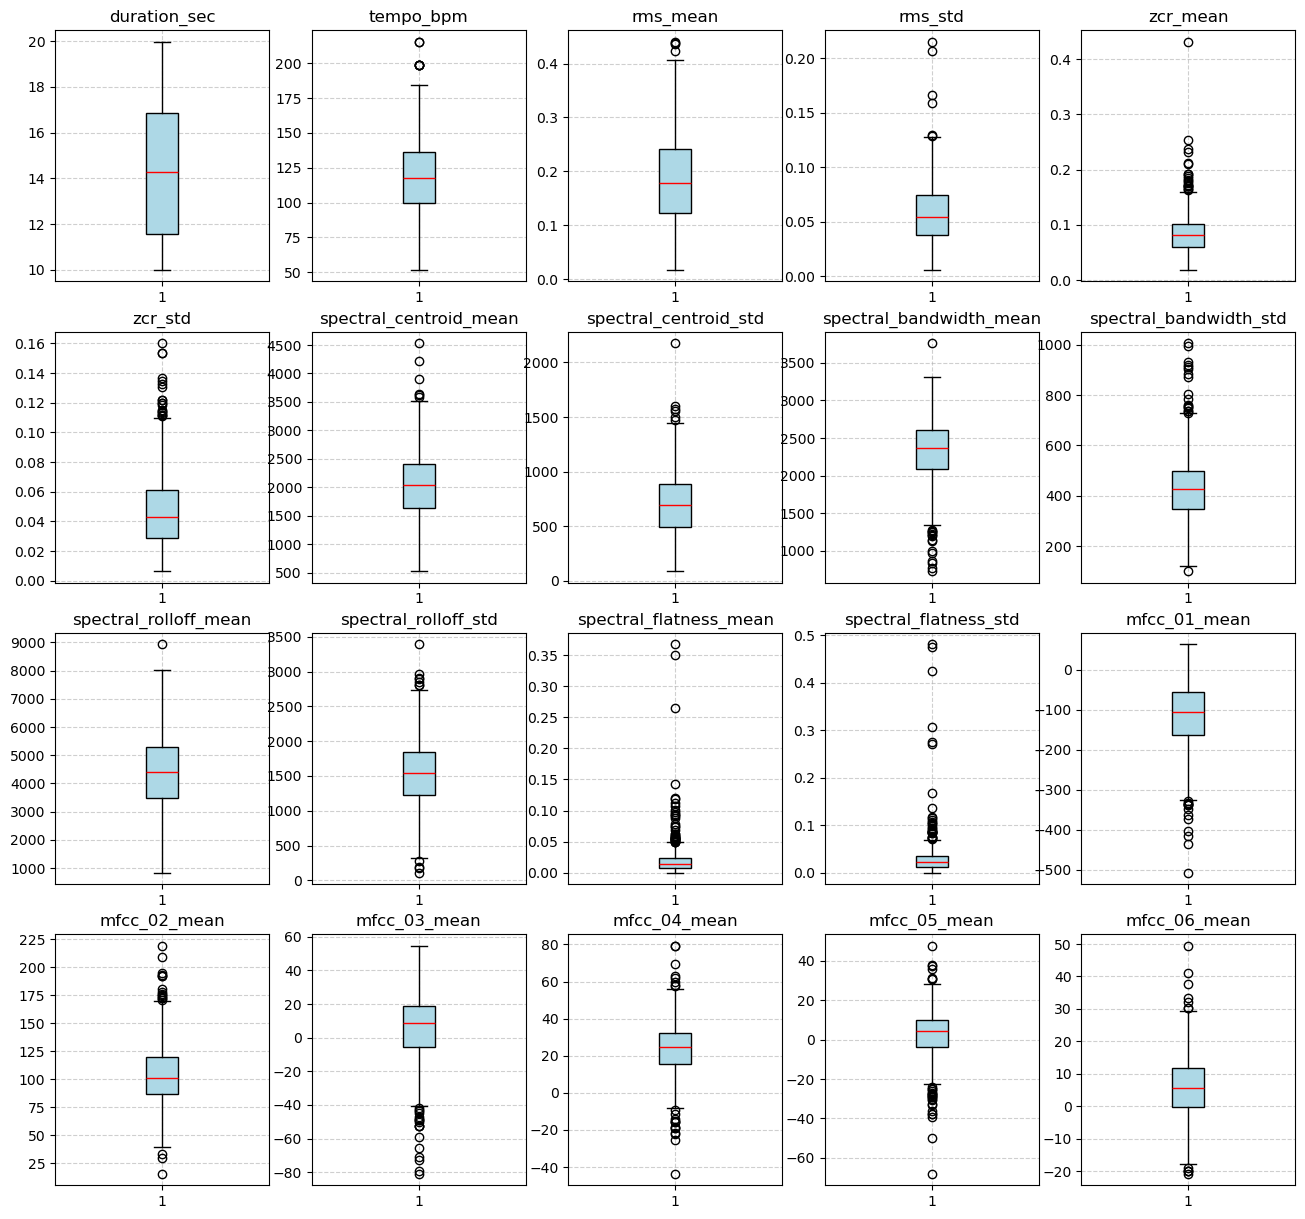

In [40]:
fig, axes = plt.subplots(4, 5, figsize=(16, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[:20]):
    axes[i].boxplot(numeric_df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()


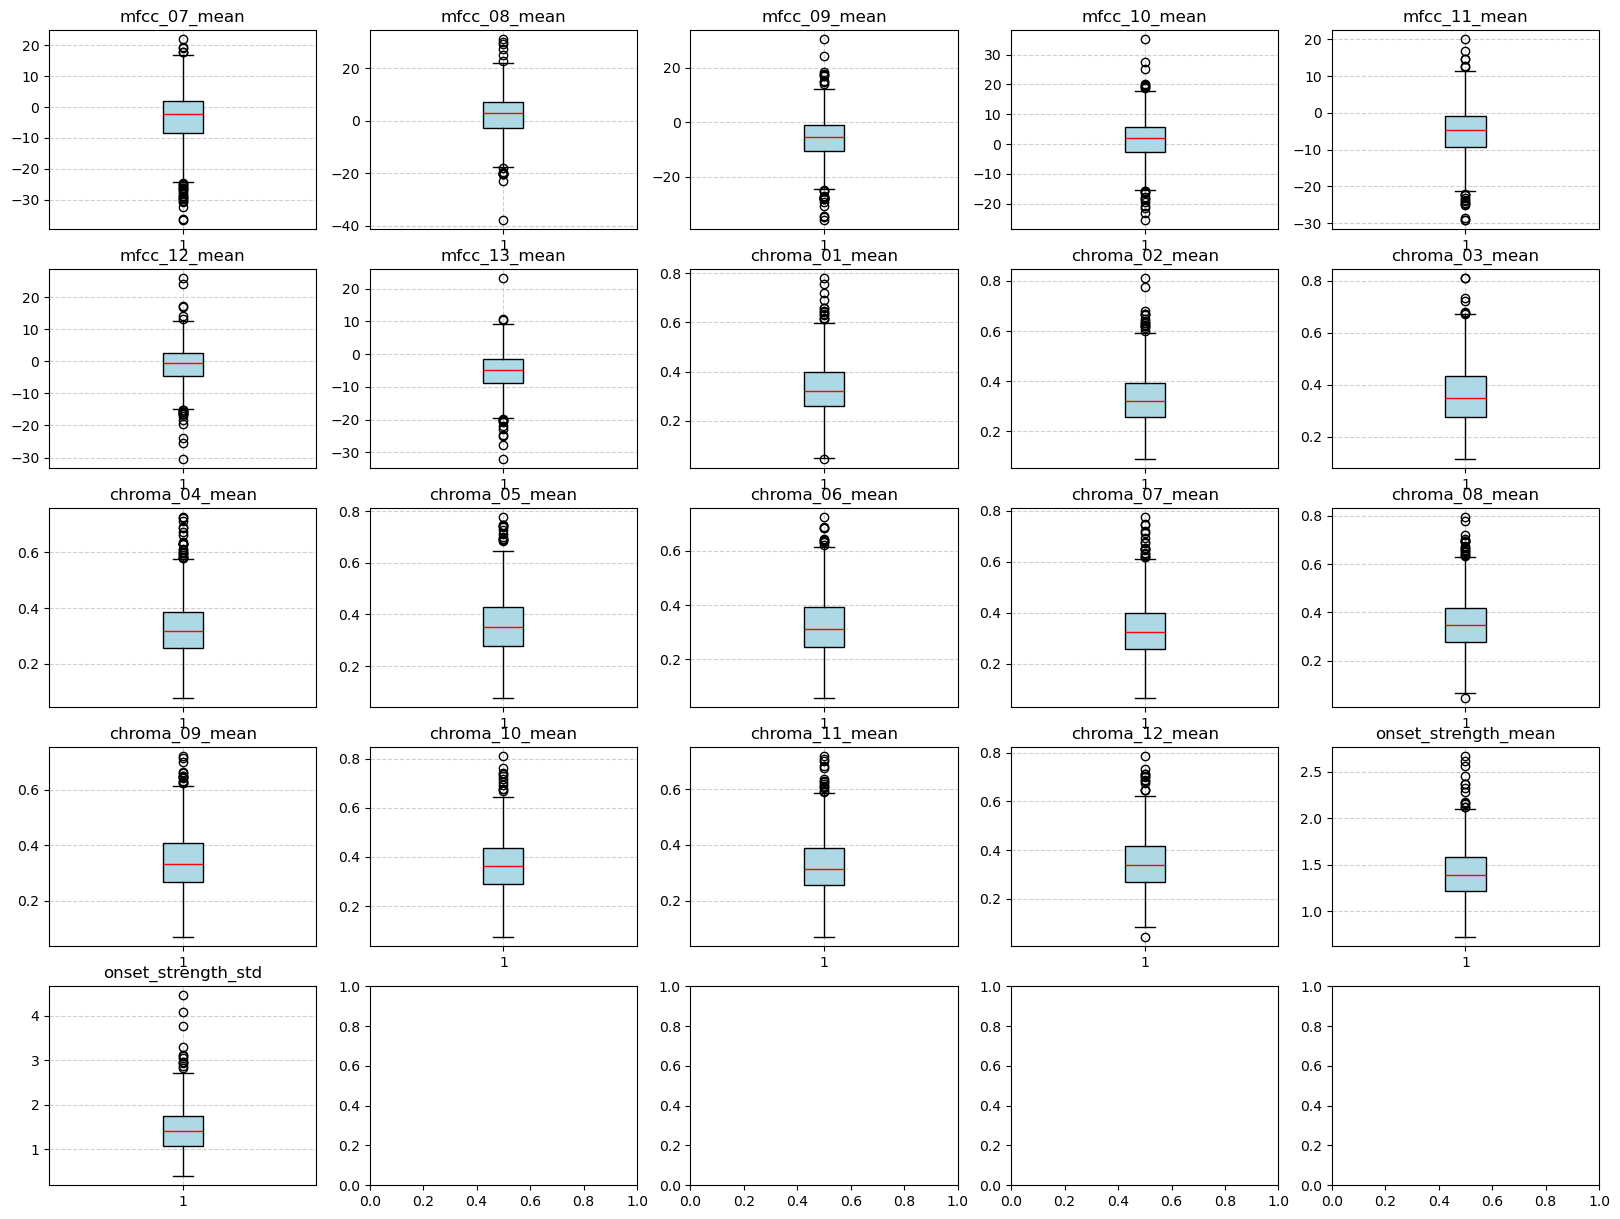

In [41]:
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[20:]):
    axes[i].boxplot(numeric_df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()

O Boxplot de todas as variaveis foi muito interessante, houve um alto numero de outliers nas variaveis diretamente relacionadas com o som da musica, como por exemplo o MFCC, Chroma e Spectral tem estes outliers. Isto pode indicar que um certo estilo de musica e mais popular do que outras, impactando a distribuição do modelo. Sera importante ver se conseguimos reduzir estes outliers para o nosso modelo.

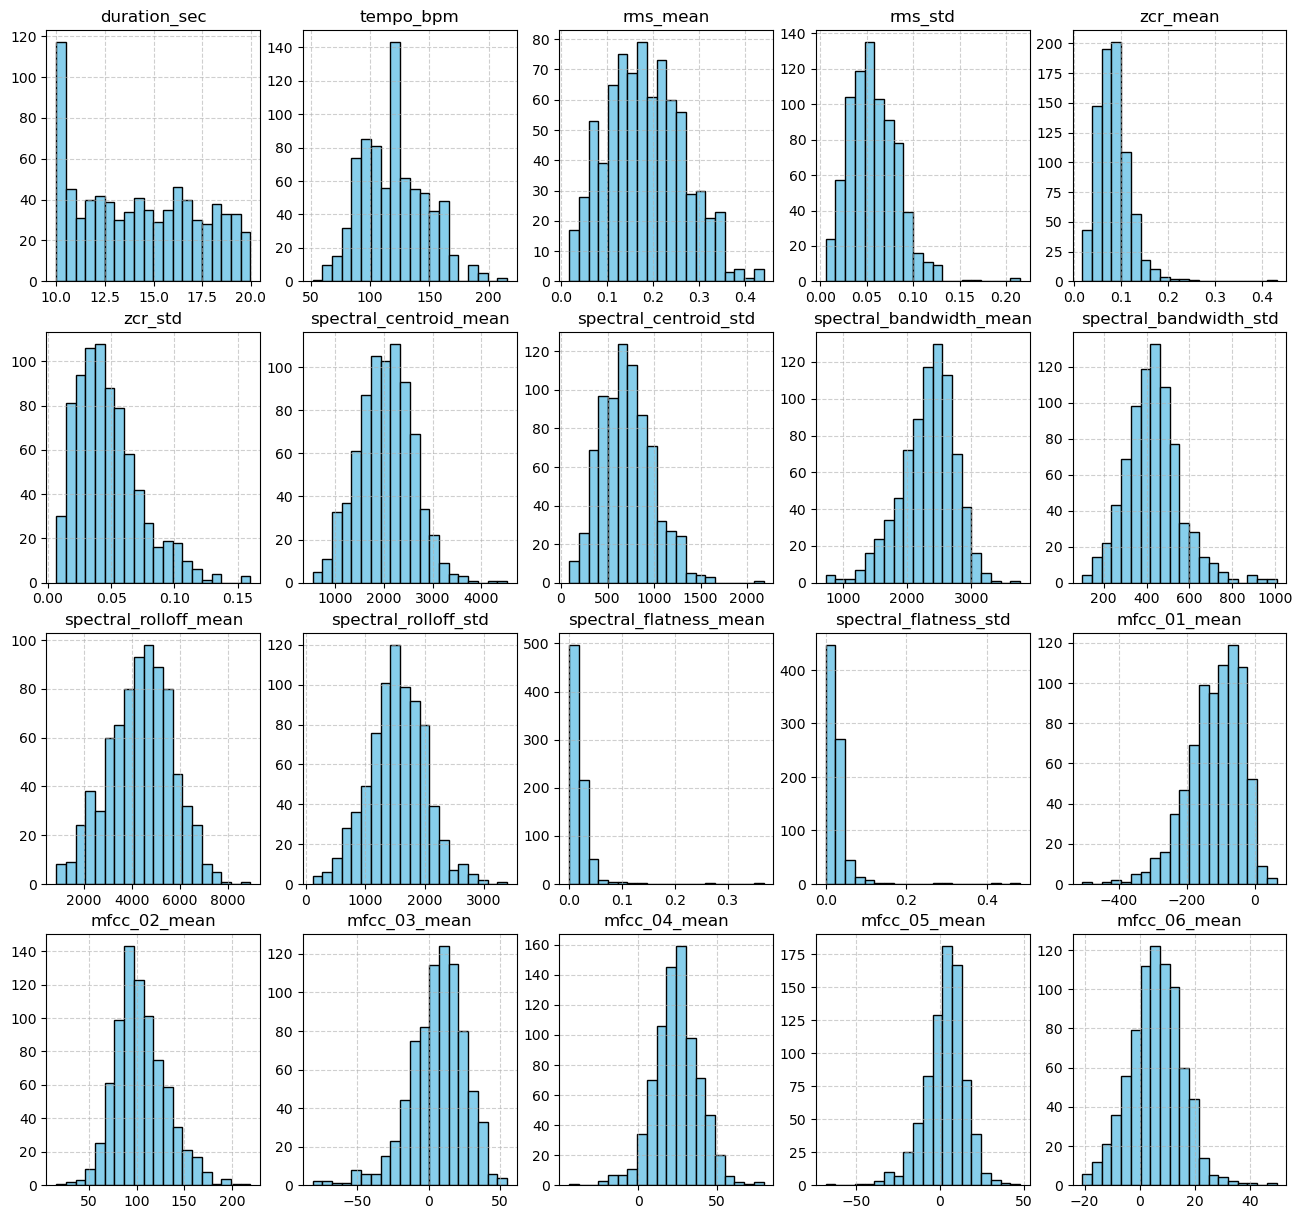

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(16, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[:20]):
    axes[i].hist(numeric_df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()

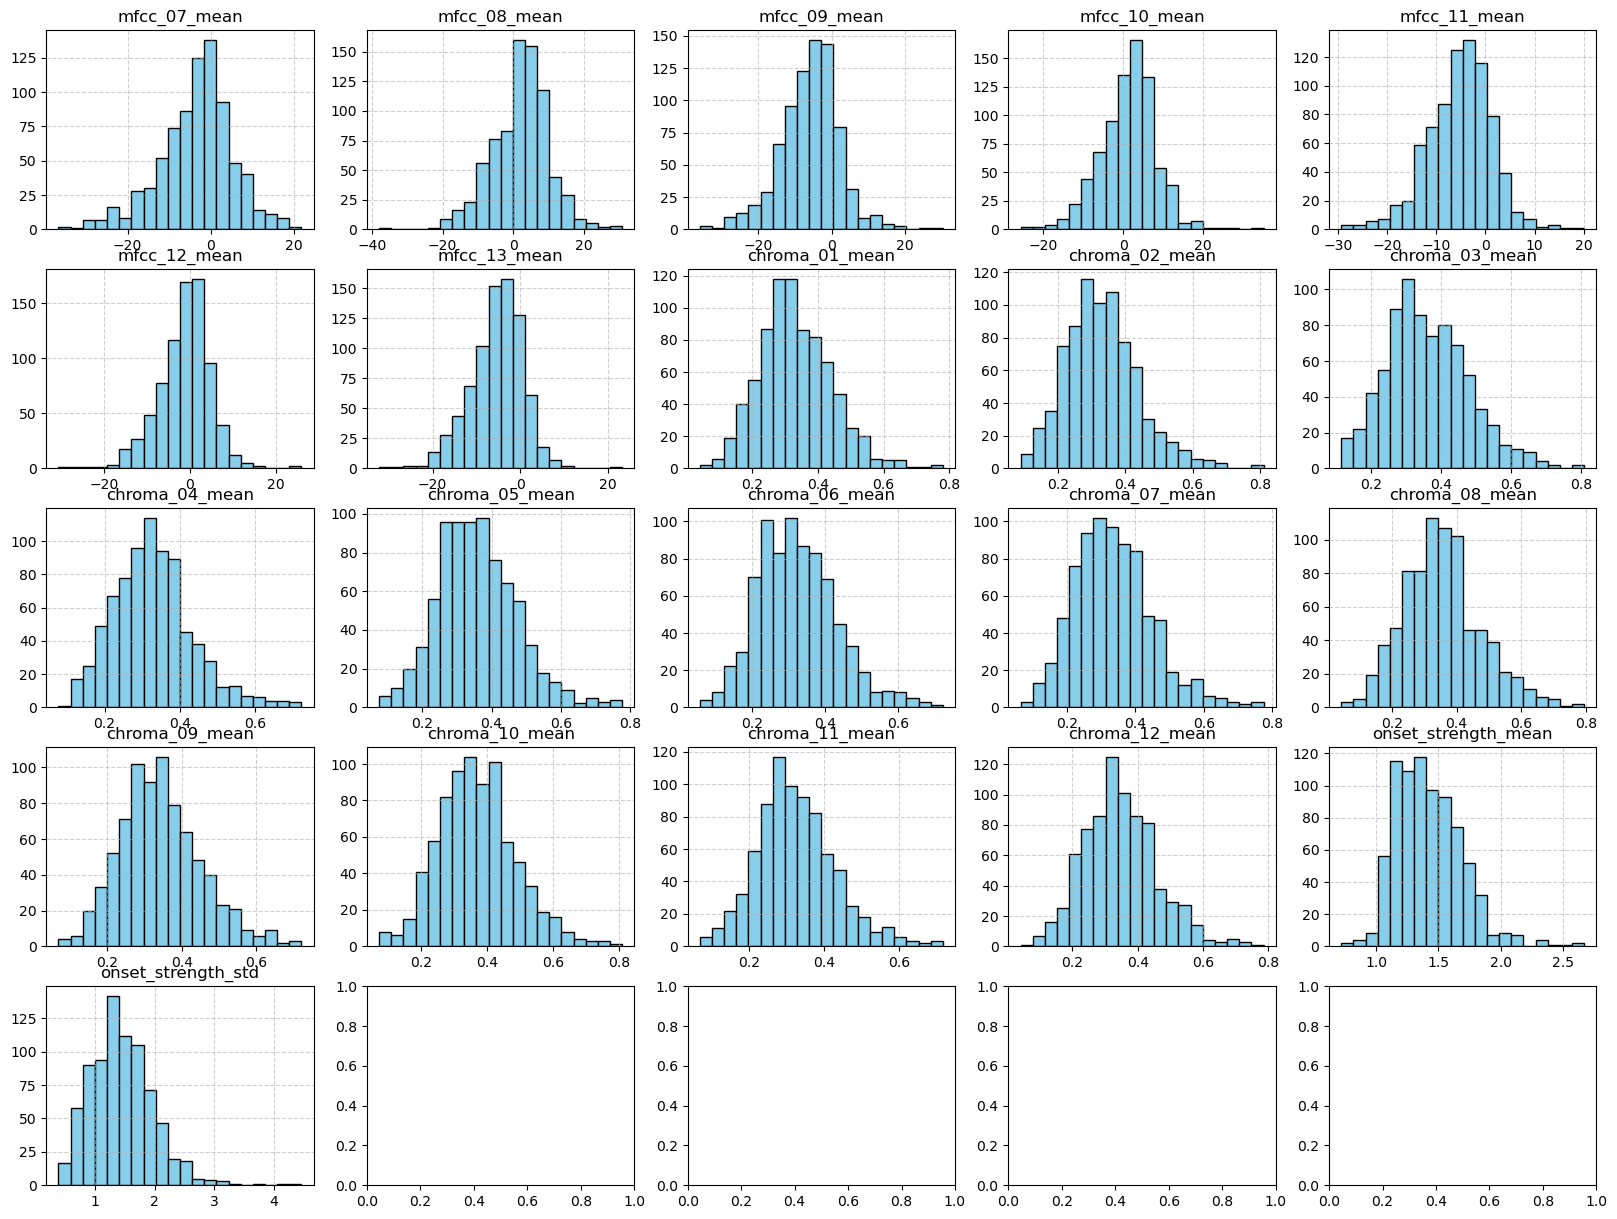

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[20:]):
    axes[i].hist(numeric_df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()

Boa parte das variaveis parecem ter uma distribuição relativamente normal, um bom indicador para o modelo conseguir adaptar aos dados, mas tem algumas exceções, algumas variaveis de mfcc apresentam uma distribuição assimetrica, como mfcc_01 e mfcc_06 apresentando uma distribuição para direita, e mfcc_02 apresentando uma distribuição assimetrica para esquerda, as variaveis de chroma parecem ter uma distribuição levemente assimetrica para direita, isto sera muito importante tentar tratar, porque pode impactar a variança que sera explicavel pelo modelo. 

# Exploração de Dados Numericos

In [50]:
categoric_df = df.select_dtypes(include='object')

categoric_df = categoric_df.drop(columns=['video_url','video_title','video_channel','artist_key','artist_name'])

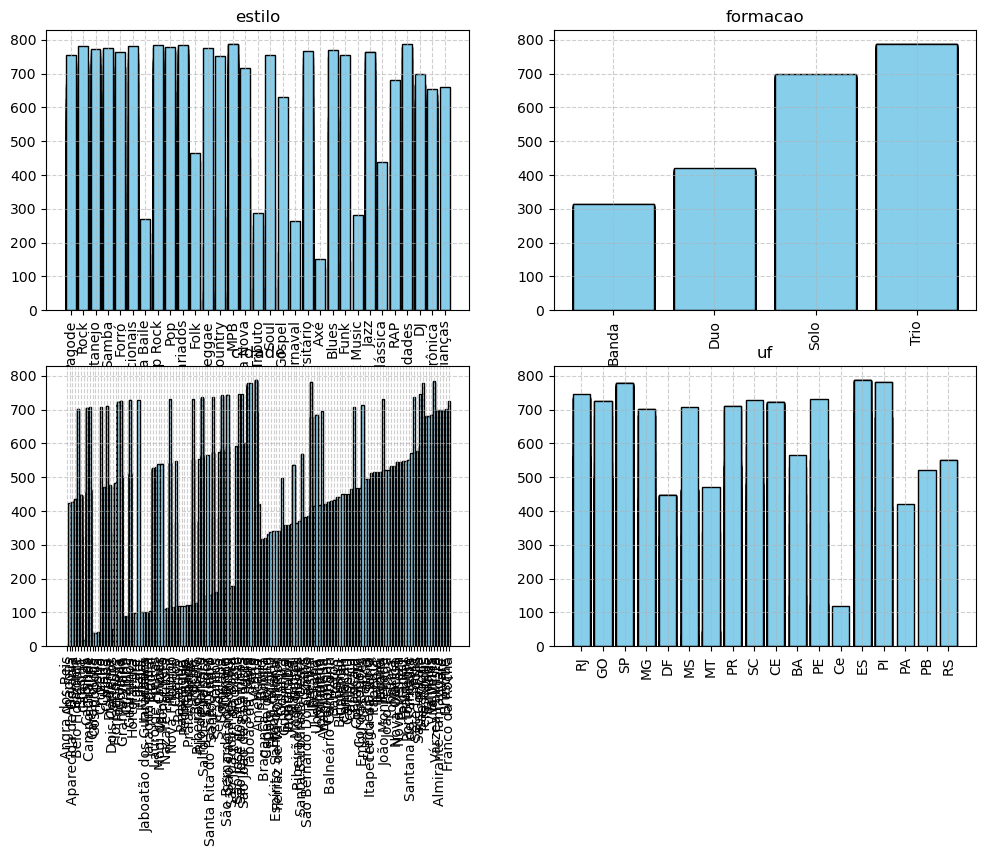

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() 

for i, col in enumerate(categoric_df.columns):
    axes[i].bar(categoric_df[col], categoric_df.index, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, linestyle='--', alpha=0.6)


plt.show()

In [145]:
display(categoric_df.groupby('uf')['cidade'].count())


uf
BA      8
CE     54
Ce      1
DF     18
ES     29
GO     40
MG     27
MS     20
MT      6
PA      1
PB      1
PE      9
PI      8
PR     25
RJ     54
RS      2
SC     21
SP    466
Name: cidade, dtype: int64

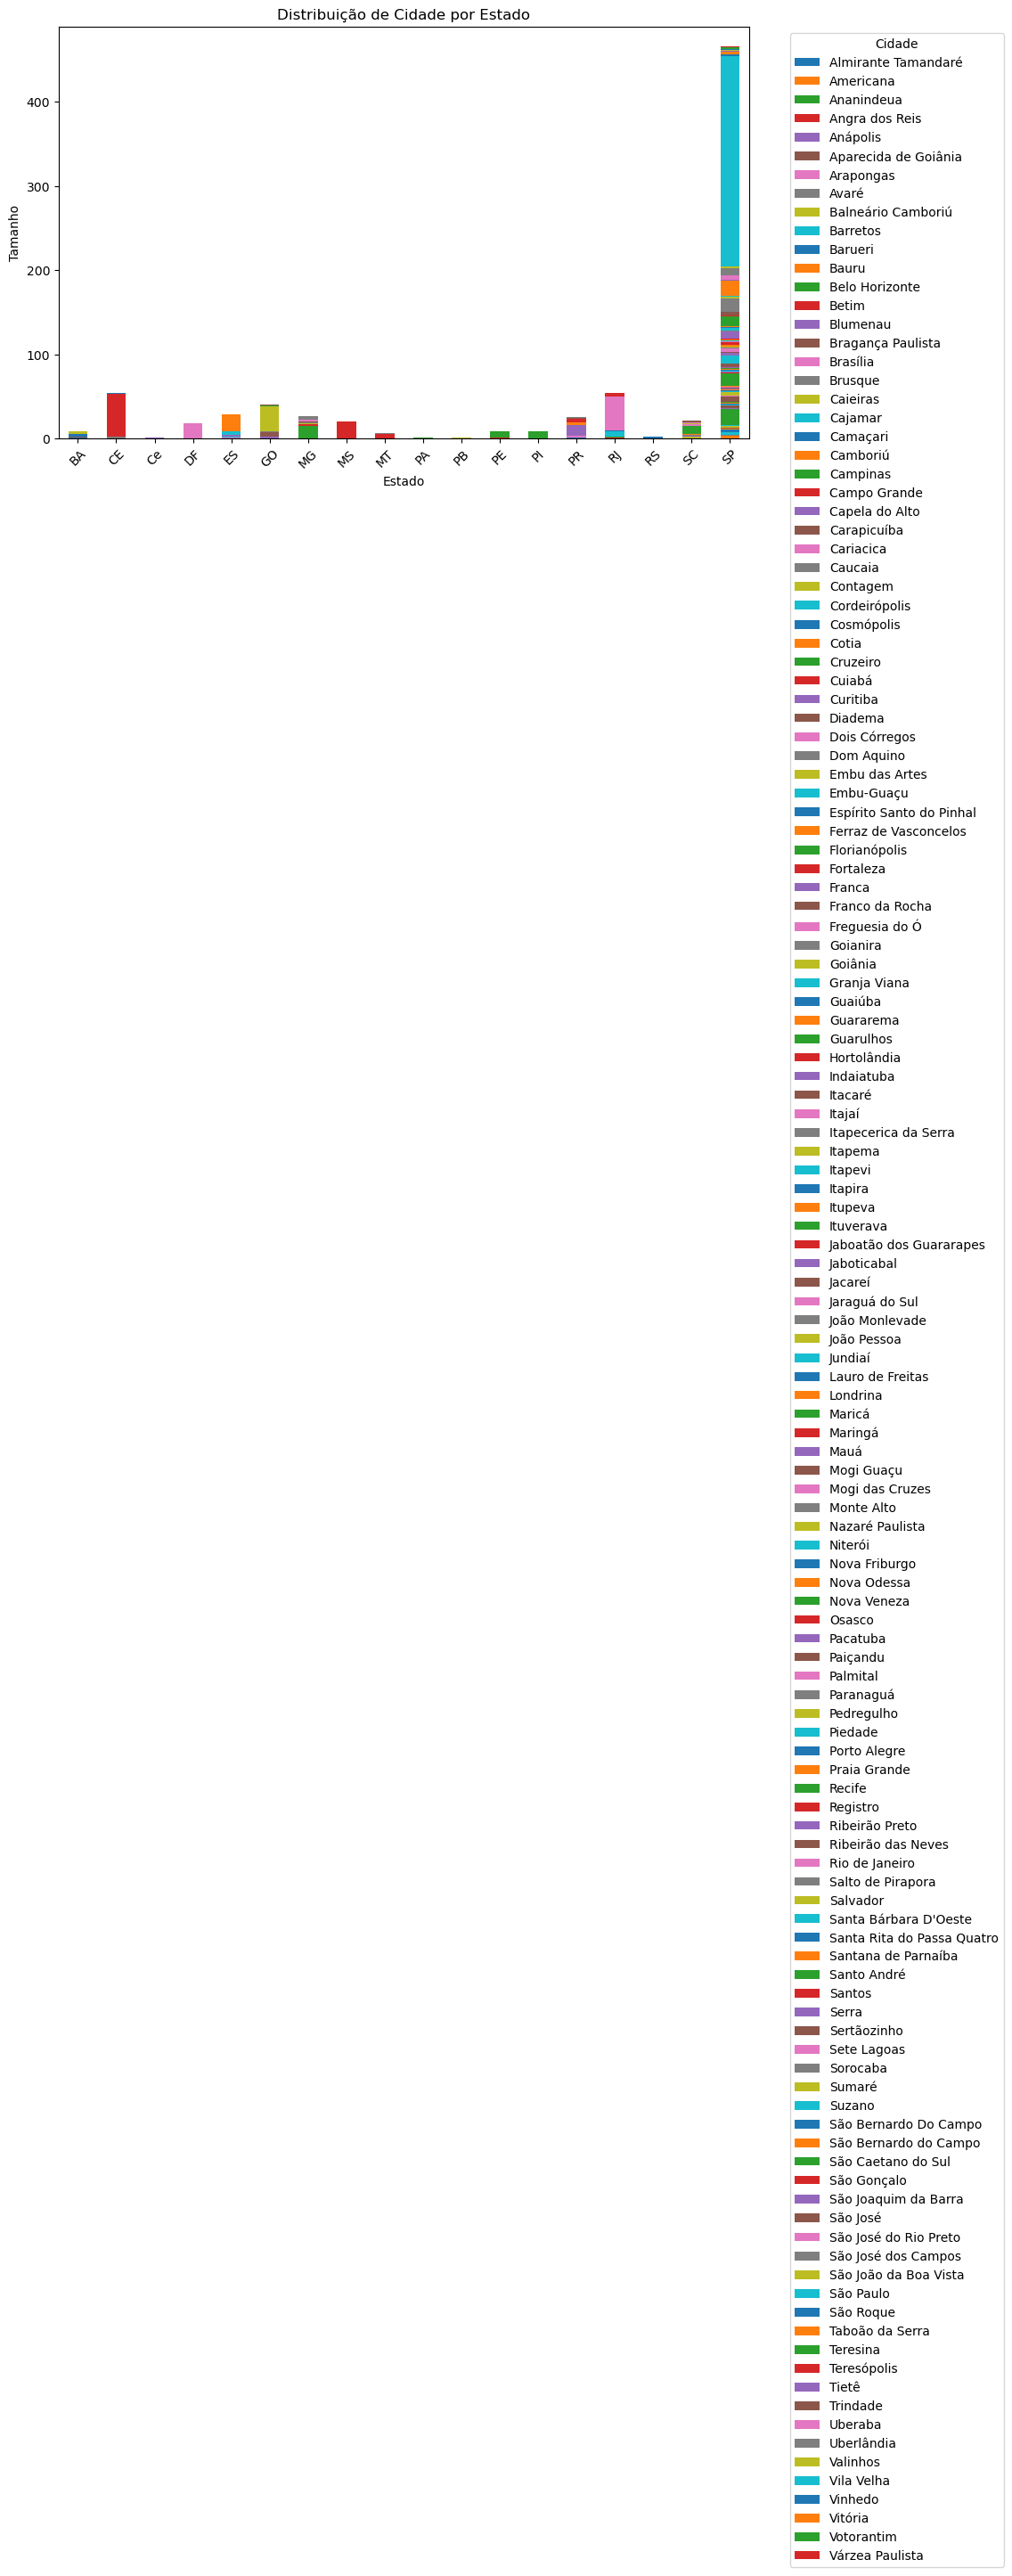

In [158]:
uf_cidades = pd.crosstab(categoric_df['uf'],categoric_df['cidade'])

ax = uf_cidades.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Distribuição de Cidade por Estado")
plt.xlabel("Estado")
plt.ylabel("Tamanho")
plt.legend(title="Cidade",loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()


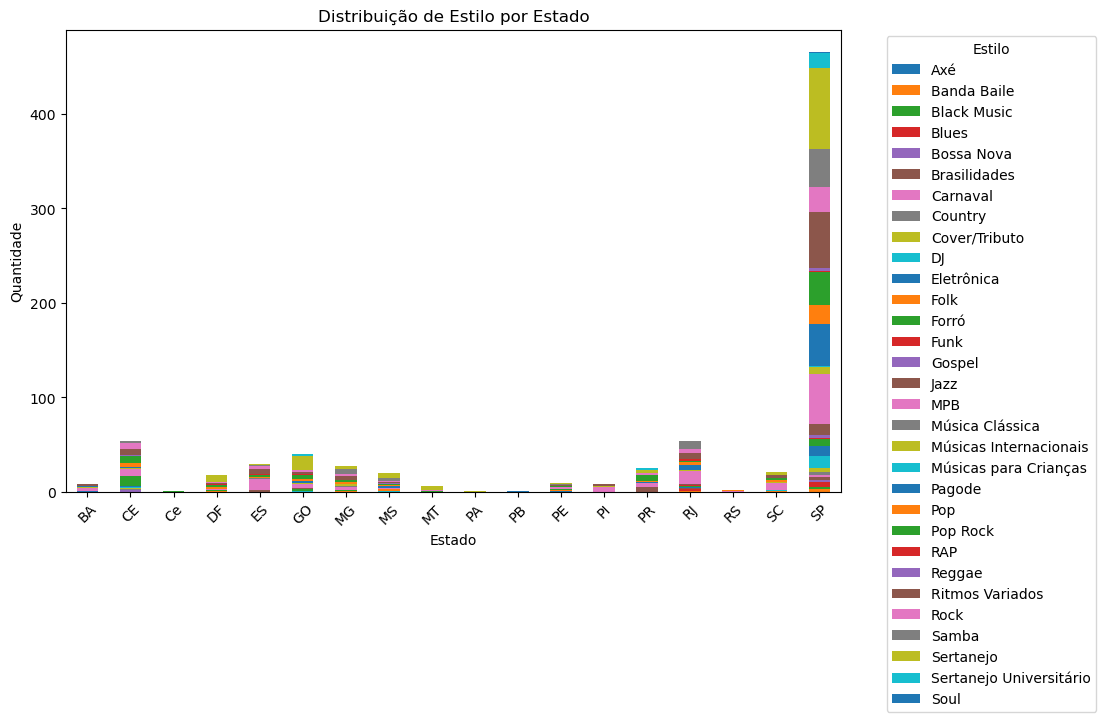

In [157]:
uf_estilo = pd.crosstab(categoric_df['uf'],categoric_df['estilo'])

ax = uf_estilo.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Distribuição de Estilo por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade")
plt.legend(title="Estilo",loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

Explorando as Cidades com o UF, podemos ver um padrão importante, houve uma concentração muito grande de bandas em SP com cidades paulistanas, seguido por RJ, seguido por CE.A abundancia de Cidades em minha opinião e ruim, e pode ser bom encontrar um jeito de simplificar a quantidade de cidades para um sistema mais simples, tipo rural vs cidade, especialmente com o fato que boa parte dos artistas estão concentrado nas capitais dos estados.

Com Formação, e interesante ver que o Trio, seguido por Solo são as formações mais communs dentro do database e Banda e o menos volumoso. Isto pode implicar um certo nivel de vies por estilos especificos de musica.

A distribuição de estilos de musica tem um nivel razoavel de representatividade, com muitos estilos como Rock, Pagode e Forro sendo similares na quantidade presente dentro do database, onde tem menos representatividade, e nos estilos como baille, Axe e Musica Classica. Seria  bom tentar introduzir um jeito de simplificar a quantidade de estilos, por classificação em estilos mais distintos, ou ate relacionar por meios de som em vez de estilo, não vejo a ideia de classificar algo como Musica International, quando pode ser um Rock, Country, Eletronica por exemplo.

Outra figura importante e a distribuição de estilo por estado. Dentro dela podemos ver que alguns estilos tem predominancia sobre outros, como Sertanejo sendo um estilo bem predominante, tambem com MBP. O que importa são os estilos que não são tão bem representados, e para isto sera melhor tentar encontrar um jeito de agrupar eles.

Em geral com estes dados categoricos, começa a ter uma imagem mais clara sobre os tipos de artistas sendo representado, conseguimos concluir que boa parte são de São Paulo, e especialmente a cidade de São Paulo. São muito provavel a ser um Trio ou Solo, e tem uma chance muito provavel de ter estilos bem variados.

# Exploração de Variaveis Numericas

In [105]:
df_corr = pd.merge(df,df_raw,on='artist_id')

In [106]:
df_corr = df_corr.drop(columns=['video_url','video_title','video_channel','artist_key','artist_name','estilo','formacao','uf','cidade','artist_id'])

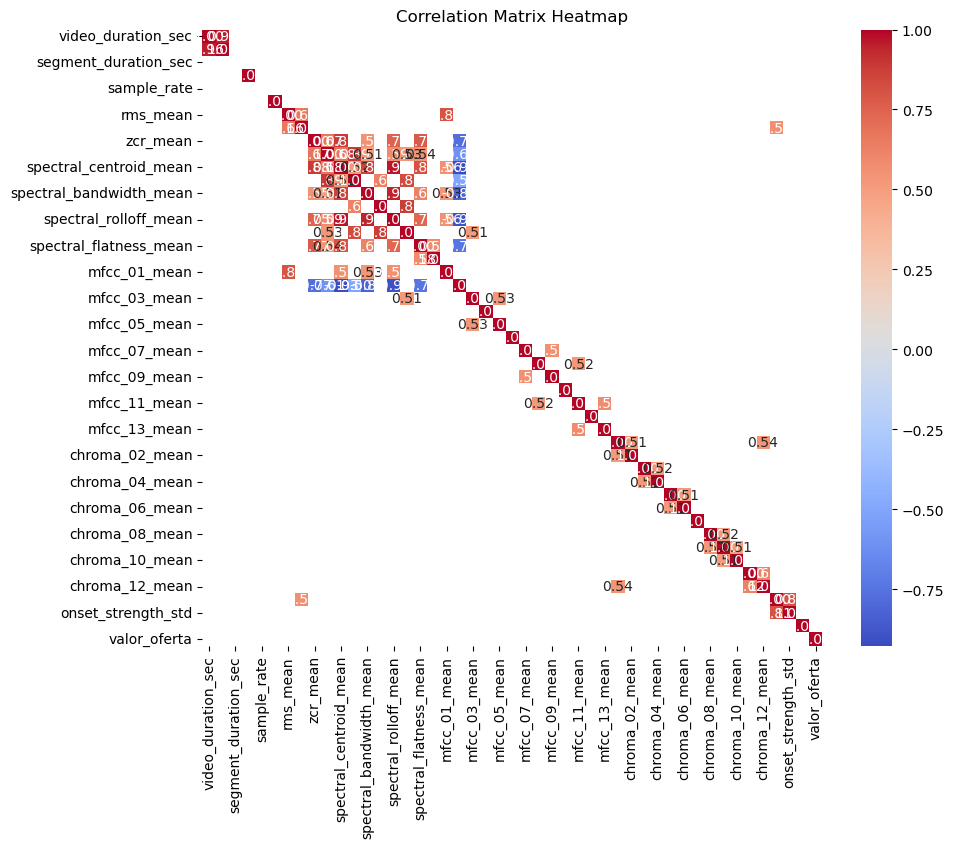

In [115]:
corr = df_corr.corr()
mask = np.abs(corr) < 0.5

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

Com uma matriz de correlação, podemos ja ver que o valor_oferta e nota não tem niveis de correlação com as features inclusas. Sendo que a matriz de correlação so lida com um relacionamento linear, e provavel que Nota e Oferta são relações não lineares.

Fora disso, presente dentro da matriz, tem um alto nivel de multicolineridade entre certas variaveis, como por exemplo o spectral_rolloff e spectrall_bandwidth sendo fortemente relacionado entre si, ou mfcc_03 tambem sendo fortemente negativamente relacionado com spectral_rolloff. Isto vai ser um problema importante para tentar resolver, vai precisar certamente aplicar um nivel de regularização para simplificar o modelo. Em geral parece que as variaveis relacionados com a parte spectral do audio e que tem um alto nivel de colineraridade entre as variaveis.

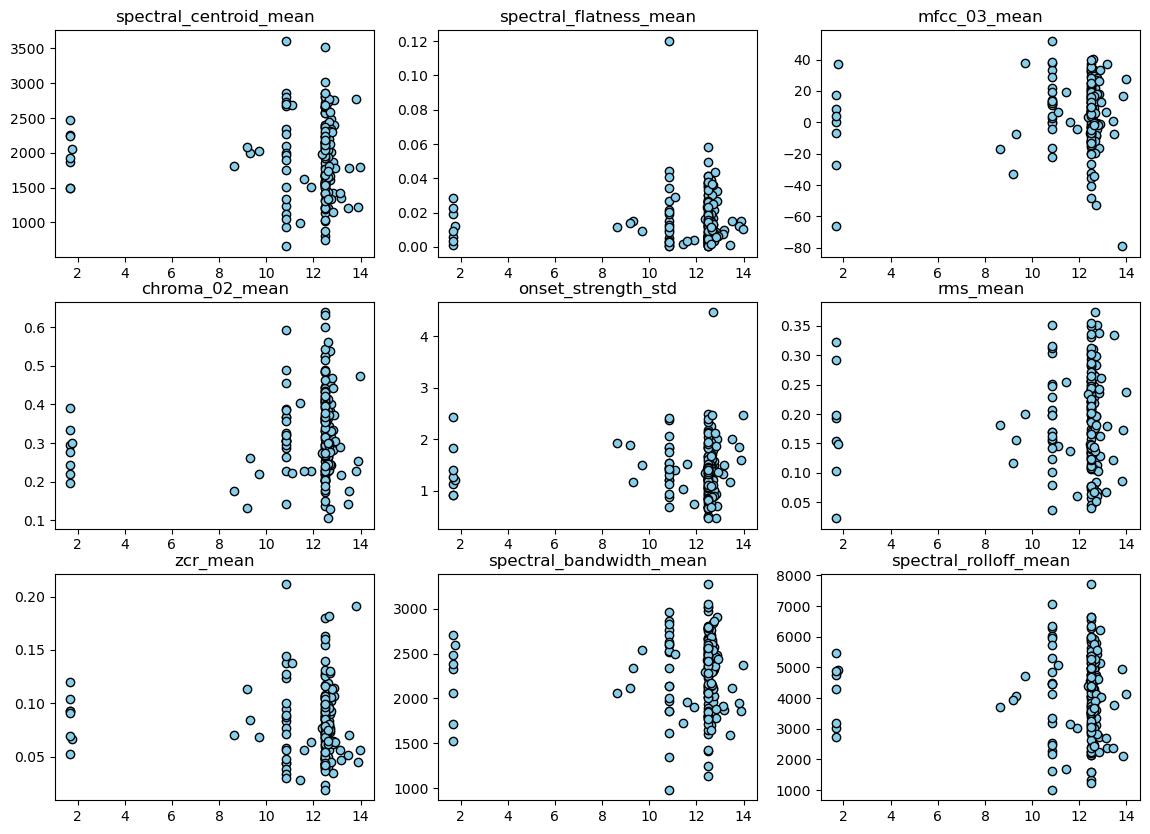

In [127]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() 

for i, col in enumerate(['spectral_centroid_mean', 'spectral_flatness_mean', 'mfcc_03_mean', 'chroma_02_mean', 'onset_strength_std', 'rms_mean','zcr_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean']):
    axes[i].scatter(df_corr.nota, df_corr[col], color='skyblue', edgecolor='black')
    axes[i].set_title(col)


plt.show()

<Axes: xlabel='nota', ylabel='Count'>

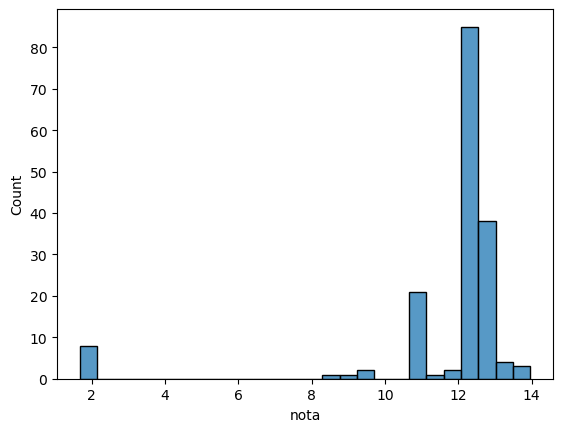

In [134]:
sns.histplot(data=df_corr,x='nota')

# Interpretação de Nota

Com Nota, houve uma distribuição muito estranha, não segue uma distribuição normal, inves sendo disperça, com forte outliers com a presença de nota 2 sendo forte, e notas entre 8 e 10 tambem. Houve uma concentração muito grande em nota 11. 

A relação entre a Nota com algumas features importantes mostram uma relação não linear bem abstrata, mas com agrupamentos bem distintos, onde houve uma separação bem forte entre grupos diferentes, se fomos utilizar a Nota para criação do modelo, e mais provavel que usaremos tipos de regressão não linear como Random Forest, para ajudar lidar com a complexidade de todas as varaveis. Com esta distribuição tambem temos uma ideia interessante, todas distribuições mostram que a maior a nota, maior o valor de chroma, spectral e zcr, indicando uma preferencia a tipos de musica mais intensivos, com mais energia.

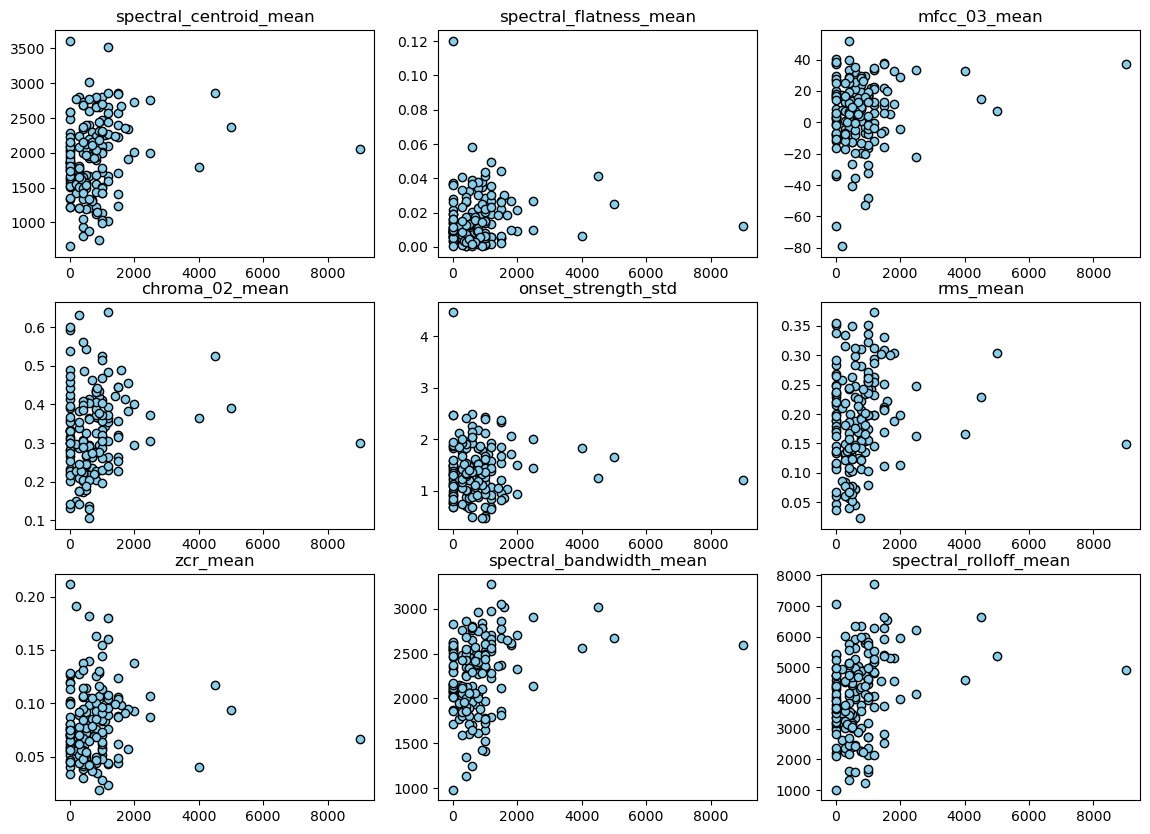

In [128]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() 

for i, col in enumerate(['spectral_centroid_mean', 'spectral_flatness_mean', 'mfcc_03_mean', 'chroma_02_mean', 'onset_strength_std', 'rms_mean','zcr_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean']):
    axes[i].scatter(df_corr.valor_oferta, df_corr[col], color='skyblue', edgecolor='black')
    axes[i].set_title(col)


plt.show()

<Axes: xlabel='valor_oferta', ylabel='Count'>

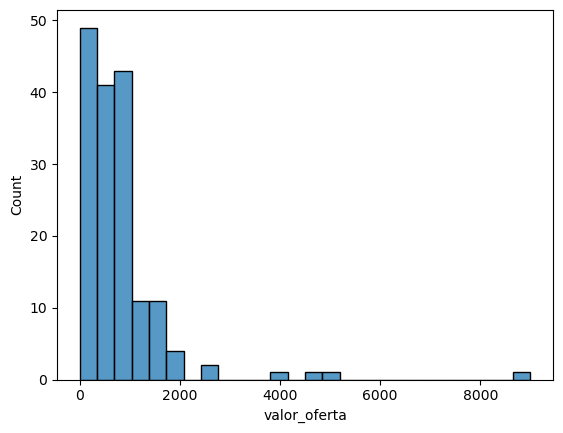

In [131]:
sns.histplot(data=df_corr,x='valor_oferta')

In [133]:
df_corr['valor_oferta'].isnull().sum()

np.int64(1)

# Interpretação de Valor Oferta

Com Valor Oferta, a distribuição tambem e muito interessante, houve outliers em oferta que cria uma assimetria para direita, especialmente com os outliers que ficam acima de 8000 de valor, fora disso boa parte dos valores existentes ficam ente 0 a 2000, onde uma parte significativa da distribuição fica entre 0 a 1000.

A relação de Valor Oferta com as features escolhidas, houve diferencas interessantes entre como as features interagem com o Valor Oferta. Em comparação a Nota, onde toda feature escolhida tinha uma distribuição muito similar entre si, o Valor Oferta se destaca tendo um grupo singular mais definido, onde boa parte dos valores se concentram por volta de um ponto unico, que pode deixar agrupamento mais singular, com menos grupos sendo formados, então pode ser melhor incluir faixas, com cortes mais focados em classificando dependendo do valor, pode ser 0 ate 1000 são Baixo Valor, 1000 ate 2000 para Medio Valor, e qualquer coisa acima sendo Alto Valor. Se utilizamos o valor oferta para o valor preditor do nosso modelo, pode ser interessante incorporar algo como Random Forest, que possa ajudar classificar o modelo quando tem uma distribuição muito diferente da norma.



# Insights Finais

Um insight que tenho e tem que incluir alguma forma de redução de features dentro dentro do modelo (Reduzir Dimensionalidade, PCA e Regularização). Simplesmente dentro do modelo, houve distribuições muito similares entre si, como por exemplo a distribuição de todas as variaveis de mfcc e chroma são extremamente similares, com so algumas diferenças em som, seria bom tentar criar uma variavel que poderia agrupar todos estas variaveis similares para criar uma que consegue representar o impacto sem necessitar a inclução de mais variaveis, que podem criar overfitting pela presença de todas as variaveis.

Para fazer isto, deveria aplicar ou regularização dependente do numero de features que nos usaremos, ou um PCA para ajudar reduzir quantas features temos.

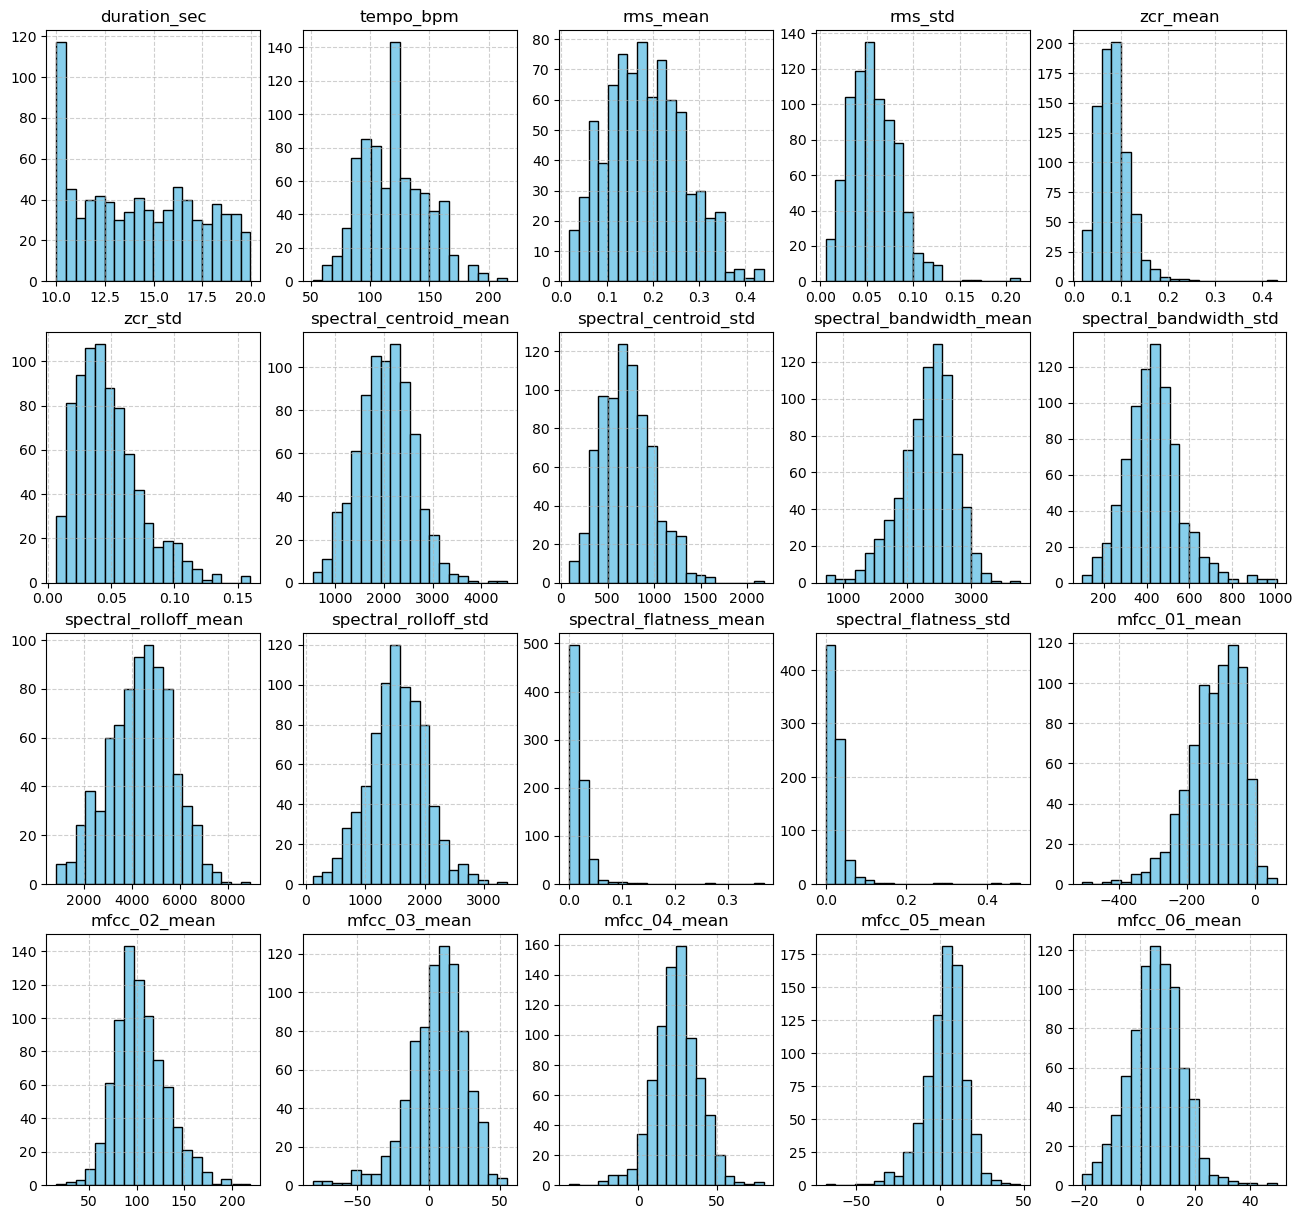

In [161]:
fig, axes = plt.subplots(4, 5, figsize=(16, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[:20]):
    axes[i].hist(numeric_df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()

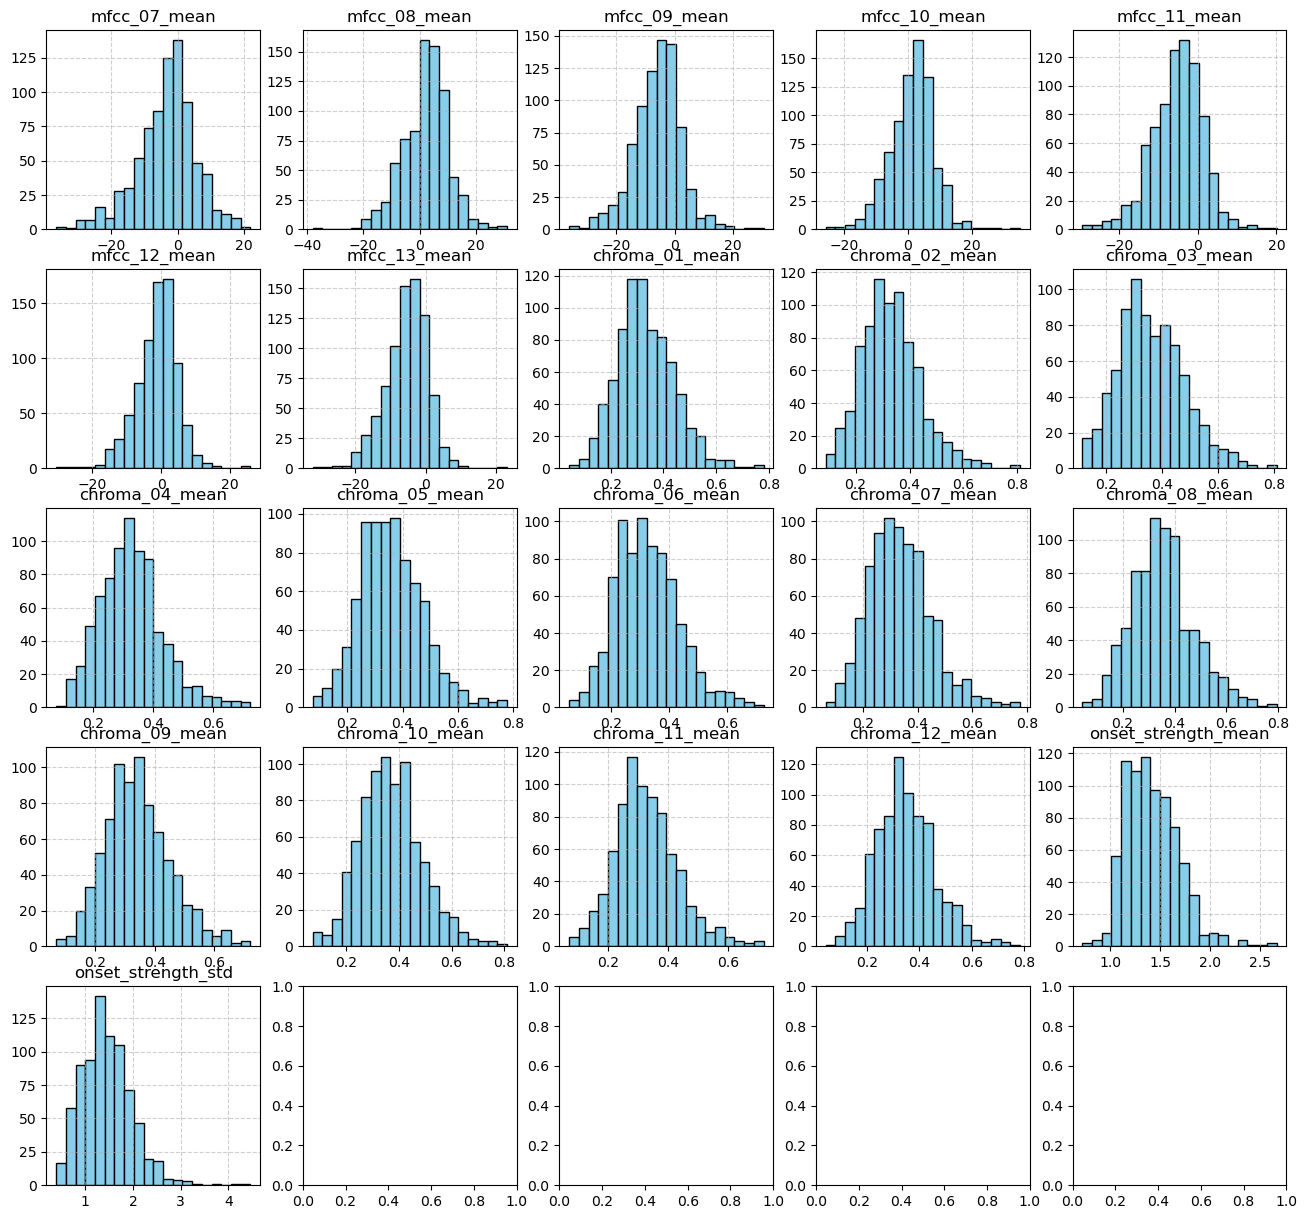

In [162]:
fig, axes = plt.subplots(5, 5, figsize=(16, 15))
axes = axes.flatten() 

for i, col in enumerate(numeric_df.columns[20:]):
    axes[i].hist(numeric_df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()

Outro insight e que necessita uma padronização dos valores, como os graficos abaixo mostram, houve uma grande variação de cidades e estilos disponiveis, mas que boa parte são redundantes, com so alguns valores sendo mais populares do que outros. Como estas são variaveis categoricas, separando estas variaveis podem criar muitas variaveis redundantes, que pode gerar um alto grau de overfitting por ter muitos features. A solução sendo para simplificar estes features, agrupando eles por outros meios, como rural vs cidade, Sertanejo e Sertanejo Universitario para Sertanejo, retirando Musicas Internationais e pondo elas no genero especifico como Pop ou Rock.

Criando um padrão vai ajudara deixar o modelo menos complexo, ajudando com a previsiblidade que modelo podera ter porque o modelo vai aprender mais o padrão dos dados inves do ruido do dado.

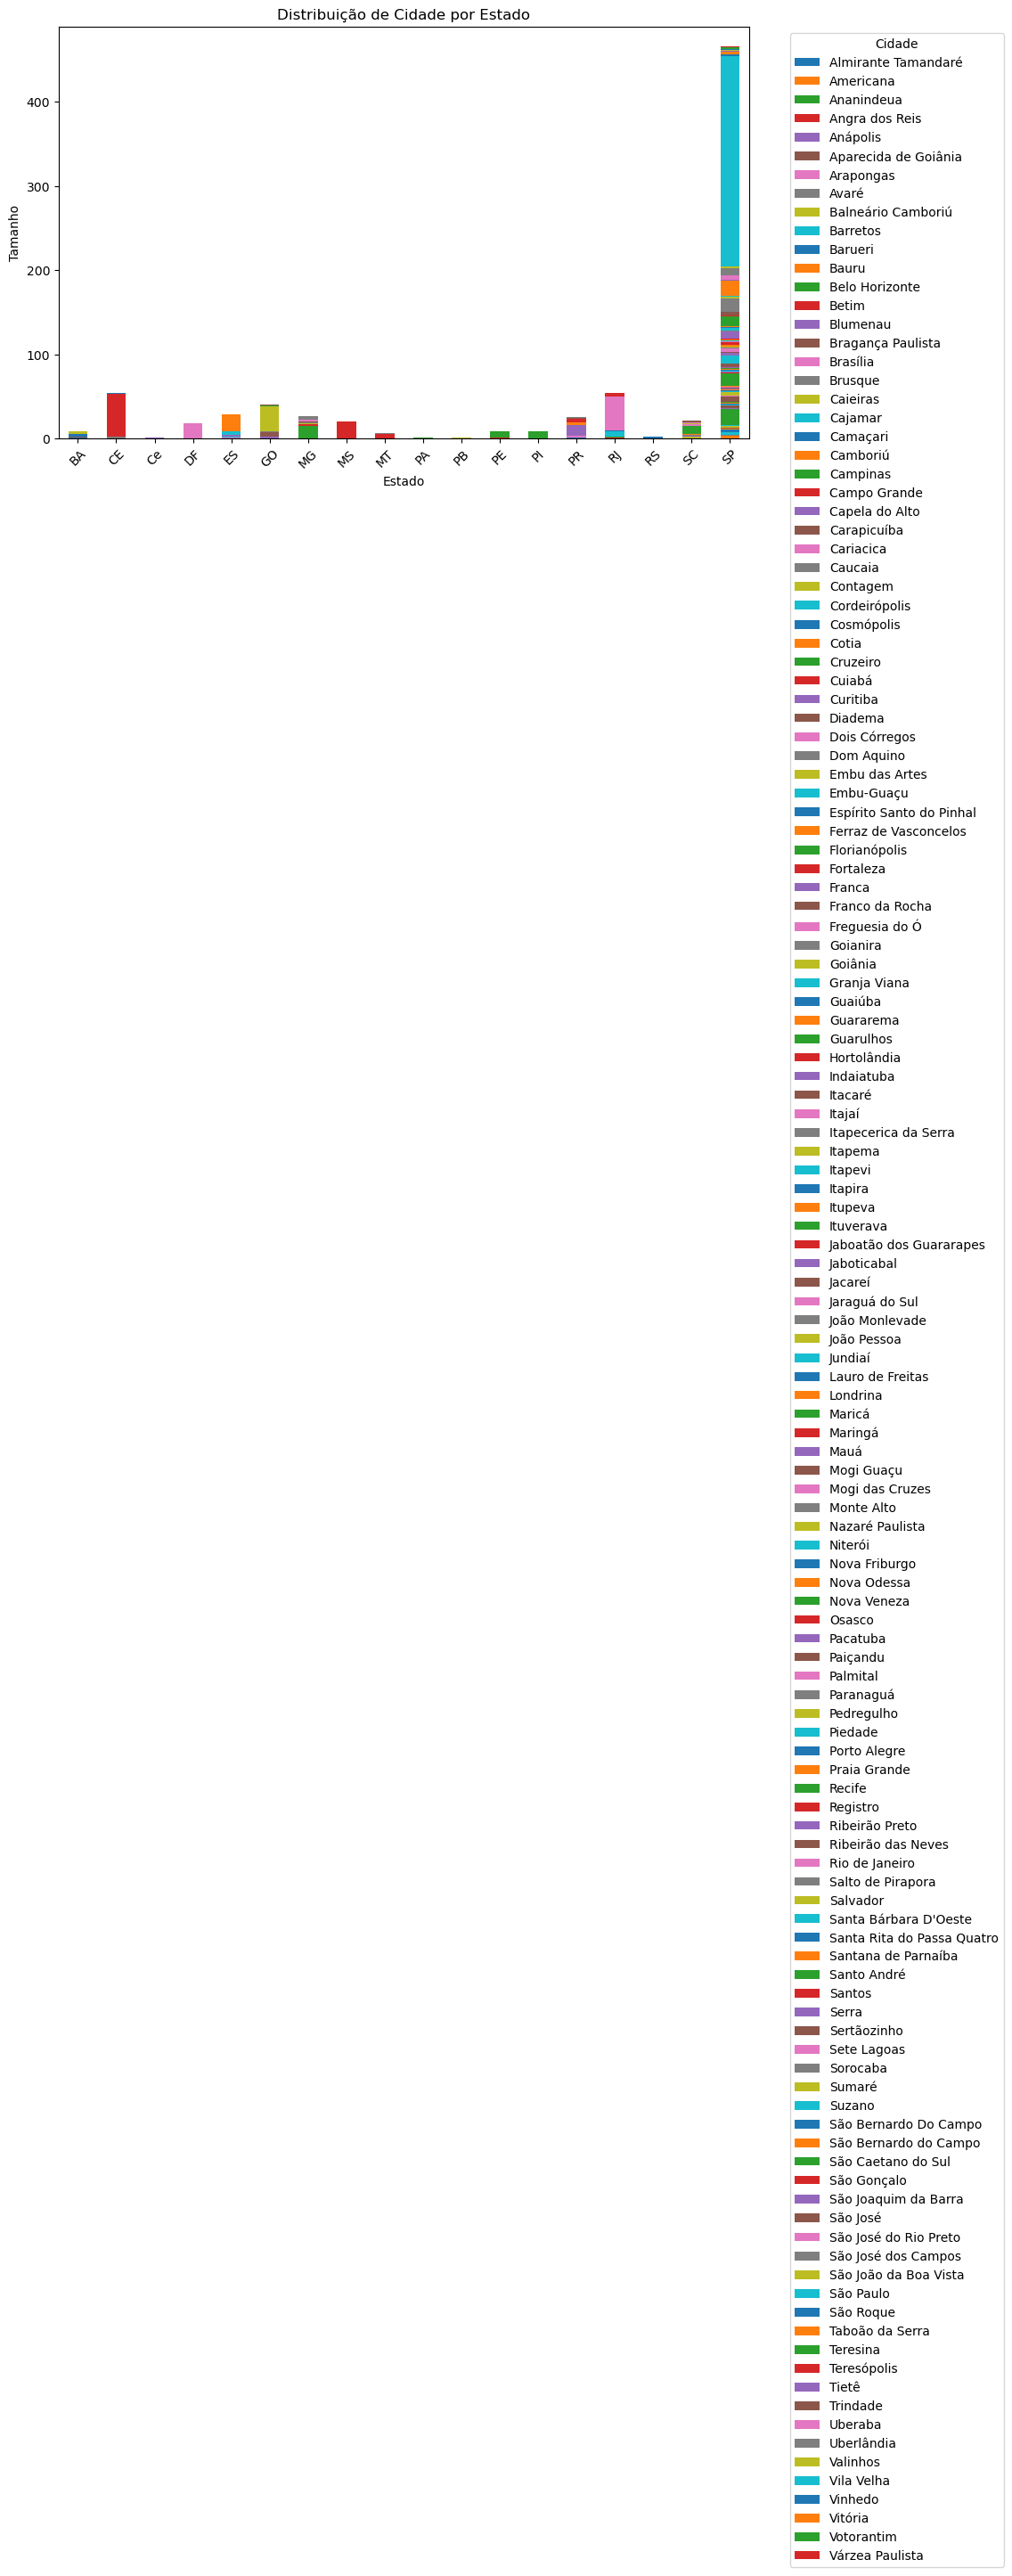

In [159]:
ax = uf_cidades.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Distribuição de Cidade por Estado")
plt.xlabel("Estado")
plt.ylabel("Tamanho")
plt.legend(title="Cidade",loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

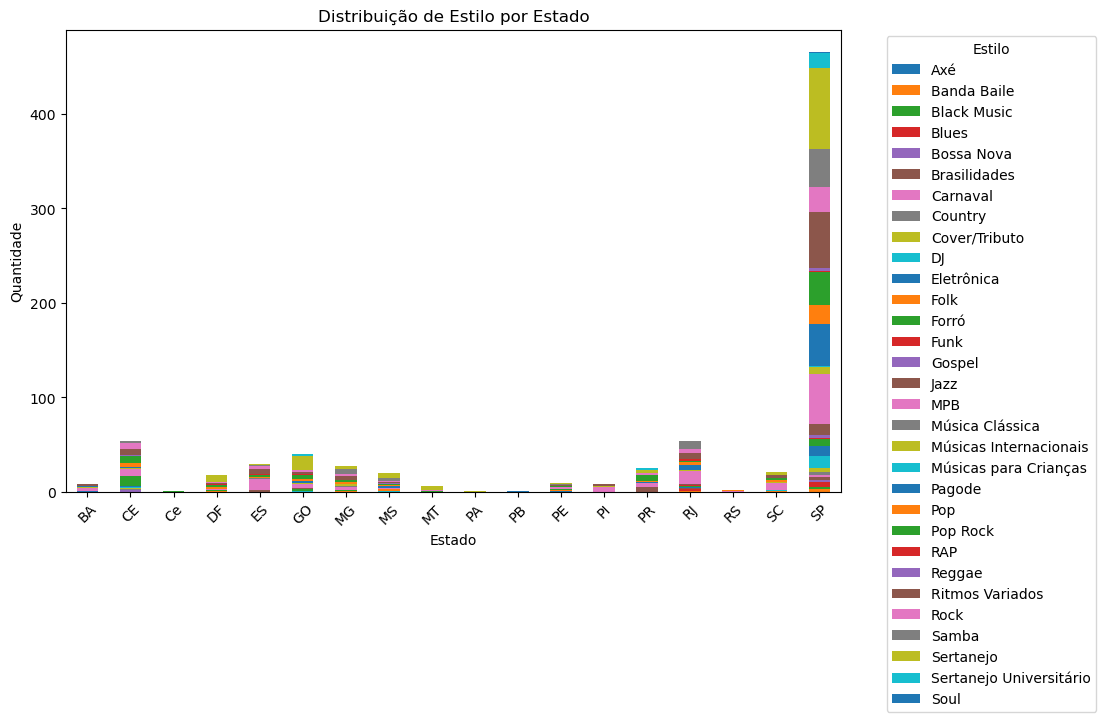

In [160]:
ax = uf_estilo.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Distribuição de Estilo por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade")
plt.legend(title="Estilo",loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

Um outro insight e que necessita uma regressão não linear mais complexa do que polinomial. E Plenamente obvio pelas distribuições que regressão polinomial não vai conseguir fazer um ajuste bom nos dados, e que um outro sistema de classificação e necessario para conseguir prever o valor oferta ou nota, com a distribuição, parece que um modelo de Random Forest, KNN ou SVR vão ser necessarios para conseguir fazer um ajuste bom nos dados para o modelo.

Adicionalmente um insight final e que potencialmente necessetira a presença de clustering e classificação dependente no que vamos fazer, para valor_oferta, pode ser bom considerar um cluster, criando um modelo que ajuda definir qual tipo de oferta deveria ser dado dependendo do que e considerado importante. Enquanto com nota, um sistema de classificação possa mais interessante, com um objetivo mais focado em classificar.

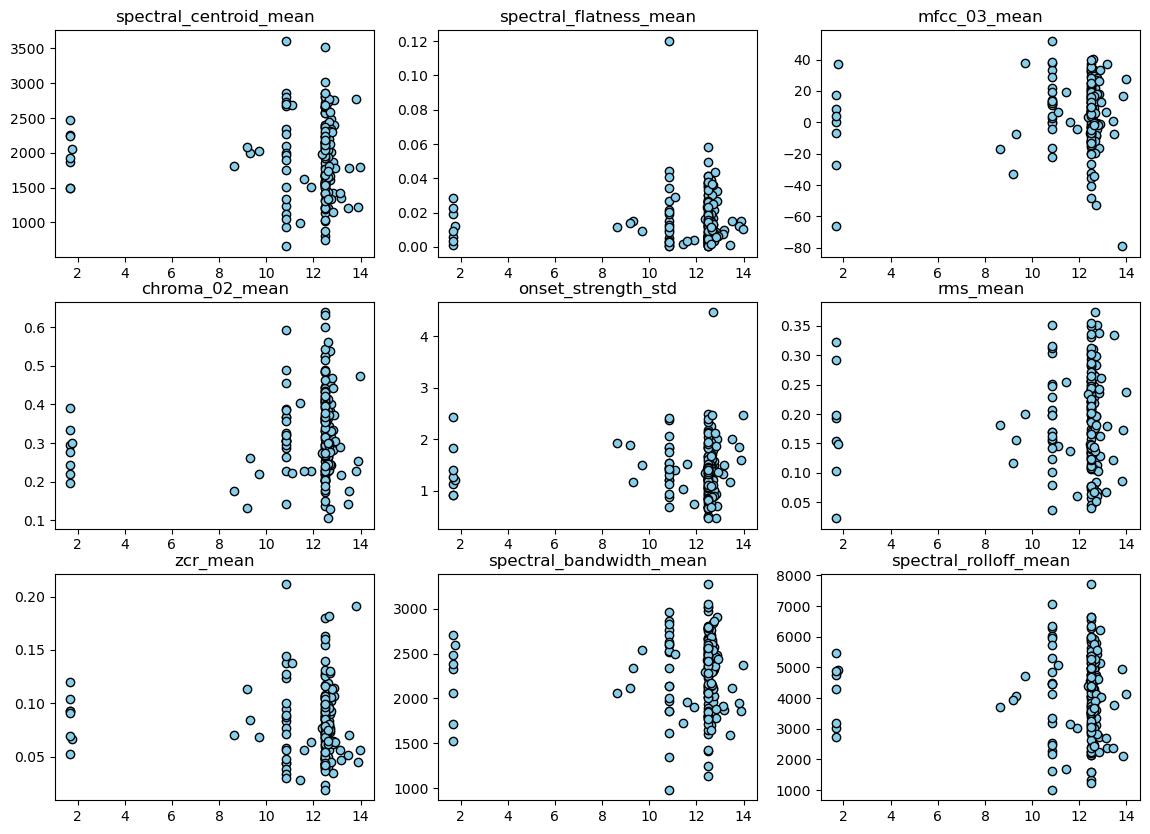

In [164]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() 

for i, col in enumerate(['spectral_centroid_mean', 'spectral_flatness_mean', 'mfcc_03_mean', 'chroma_02_mean', 'onset_strength_std', 'rms_mean','zcr_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean']):
    axes[i].scatter(df_corr.nota, df_corr[col], color='skyblue', edgecolor='black')
    axes[i].set_title(col)


plt.show()

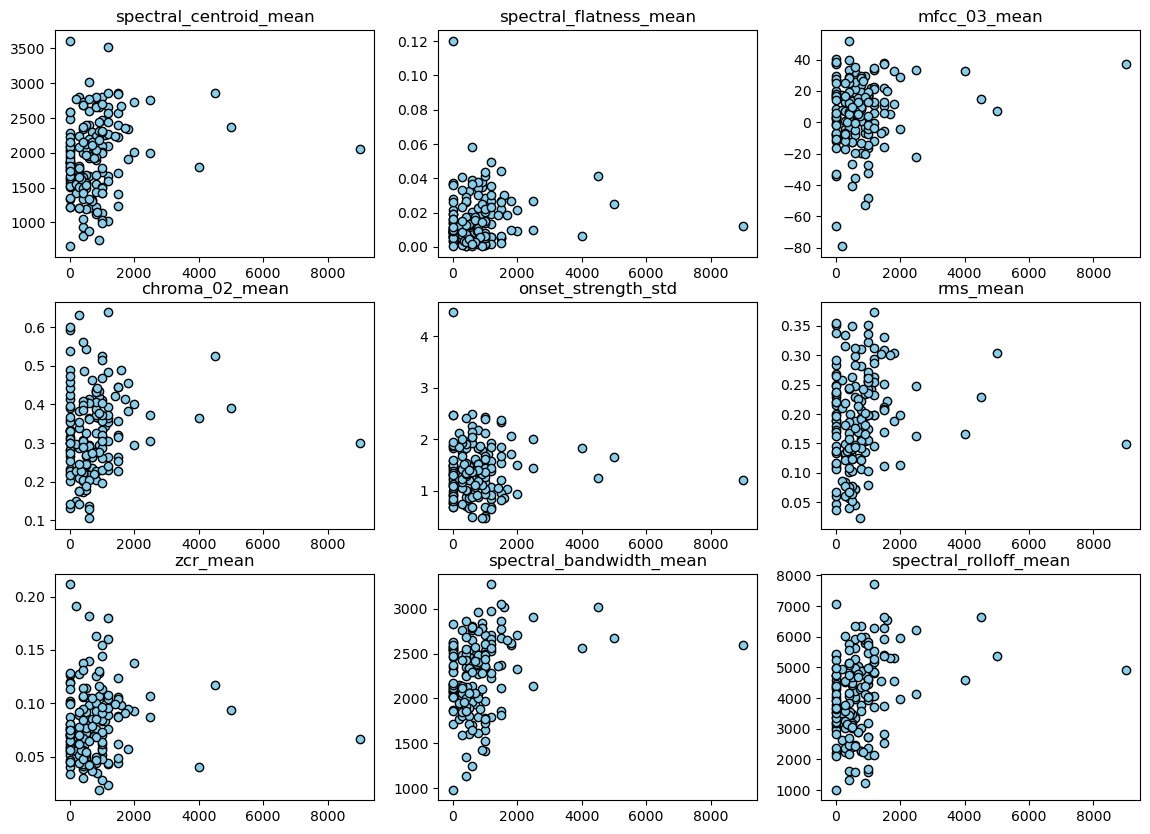

In [163]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() 

for i, col in enumerate(['spectral_centroid_mean', 'spectral_flatness_mean', 'mfcc_03_mean', 'chroma_02_mean', 'onset_strength_std', 'rms_mean','zcr_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean']):
    axes[i].scatter(df_corr.valor_oferta, df_corr[col], color='skyblue', edgecolor='black')
    axes[i].set_title(col)


plt.show()

Antecipo que os maiores riscos seram com data leakage. O projeto necessita uma forte transformação de dados, precisamos ficar com cuidade de não criar features derivadas das variaveis preditoras, e bom utilizar um sistema de cross validation com pipeline para garantir o mesmo pre-processamento de dados, uma cross validation que garante não criar uma contaminação de teste e train.

Outro risco e o tipo de padronização de dados, vamos tem que considerar qual tipo vai ser melhor para os dados para garantir o melhor fit possivel, algo que podemos ver vendo os usos de cada escalonamento e como eles vão afetar nossas features.

Outro risco tambem inclui que a padronização precisa ser considerado, como nos vamos padronizar os dados, a distribuição no grafico pode ser alterada, afetando a variança da feature que pode melhorar ou ate enviesar a variança e aumentar o ruido dos dados, então para lidar com isto, a padronização precisa ser considerado, para simplificar os dados e evitar overfitting.